# URL Shortener — Performance & Load Test Analysis

Performance evaluation of the Flask-based URL Shortener under different
concurrency levels.

### Objectives

- Measure request throughput
- Measure request latency
- Evaluate behavior under increasing concurrency
- Measure success/failure rate
- Identify potential performance bottlenecks

## 1. Test Environment

| Parameter | Value |
|---|---|
| Application | Flask URL Shortener |
| Backend | PostgreSQL |
| Database Hosting | Supabase |
| Application Environment | Local Flask Server |
| Endpoint | `POST /` |
| Test Payload | ~1 KB URL |
| Load Testing Tool | Custom Python `asyncio` + `aiohttp` |
| Maximum Tested Concurrency | 10 |
| Individual Request Timeout | 15 seconds |
| Test Timeout | 120 seconds |

> The Flask application was running locally while the PostgreSQL database was
> hosted remotely on Supabase.

## 2. Test Objective

The objective of the benchmark is to establish a performance baseline for the
URL Shortener and observe how the application behaves as the number of
concurrent requests increases.

The primary metrics measured are:

- **Throughput:** Number of successfully completed requests per second.
- **Average latency:** Mean time required to process a request.
- **P50 latency:** Median request latency.
- **P95 latency:** Latency within which 95% of requests completed.
- **P99 latency:** Latency within which 99% of requests completed.
- **Success rate:** Percentage of completed requests returning a successful
  HTTP response.

## 3. Test Methodology

A custom asynchronous Python load-testing script was used to send requests to
the URL Shortener.

For each request:

1. A unique approximately 1,000-character URL was generated.
2. The URL was submitted to the `POST /` endpoint.
3. The HTTP response was recorded.
4. Request latency was measured.
5. The result was classified as successful or failed.

The following workloads were tested:

| Requests | Concurrency |
|---:|---:|
| 100 | 1 |
| 500 | 5 |
| 1,000 | 10 |

Each successful POST request creates a new URL record in the PostgreSQL
database.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("load_test_results.csv")

df

Matplotlib is building the font cache; this may take a moment.


,requests,completed,concurrency,successful,failed,success_rate,total_time,avg_ms,min_ms,max_ms,p50_ms,p95_ms,p99_ms,req_per_sec
0,100,100,1,100,0,100.0,69.531264,694.516181,377.8768,3371.6699,450.7596,2721.9304,3371.6699,1.438202
1,500,500,5,500,0,100.0,59.515463,592.568781,373.1112,2142.7110,473.7162,1314.8094,1922.1311,8.401178
2,1000,1000,10,1000,0,100.0,61.699700,614.824158,366.4392,2931.2275,522.3357,1054.5338,1696.4360,16.207534


## 4. Test Results

The following results were obtained from the completed load tests.

In [3]:
summary = df[
    [
        "requests",
        "concurrency",
        "completed",
        "successful",
        "failed",
        "success_rate",
        "req_per_sec"
    ]
].copy()

summary.columns = [
    "Requests",
    "Concurrency",
    "Completed",
    "Successful",
    "Failed",
    "Success Rate (%)",
    "Throughput (req/s)"
]

summary

,Requests,Concurrency,Completed,Successful,Failed,Success Rate (%),Throughput (req/s)
0,100,1,100,100,0,100.0,1.438202
1,500,5,500,500,0,100.0,8.401178
2,1000,10,1000,1000,0,100.0,16.207534


## 5. Latency Results

Latency is evaluated using multiple statistics because average latency alone
does not show the behavior of slower requests.

- **P50** represents the median request latency.
- **P95** represents the latency experienced by the slower 5% of requests.
- **P99** represents the latency experienced by the slowest 1% of requests.

In [4]:
latency = df[
    [
        "concurrency",
        "avg_ms",
        "min_ms",
        "max_ms",
        "p50_ms",
        "p95_ms",
        "p99_ms"
    ]
].copy()

latency.columns = [
    "Concurrency",
    "Average (ms)",
    "Minimum (ms)",
    "Maximum (ms)",
    "P50 (ms)",
    "P95 (ms)",
    "P99 (ms)"
]

latency

,Concurrency,Average (ms),Minimum (ms),Maximum (ms),P50 (ms),P95 (ms),P99 (ms)
0,1,694.516181,377.8768,3371.6699,450.7596,2721.9304,3371.6699
1,5,592.568781,373.1112,2142.7110,473.7162,1314.8094,1922.1311
2,10,614.824158,366.4392,2931.2275,522.3357,1054.5338,1696.4360


## 6. Throughput vs Concurrency

This graph shows how the number of completed requests per second changes as
the concurrency level increases.

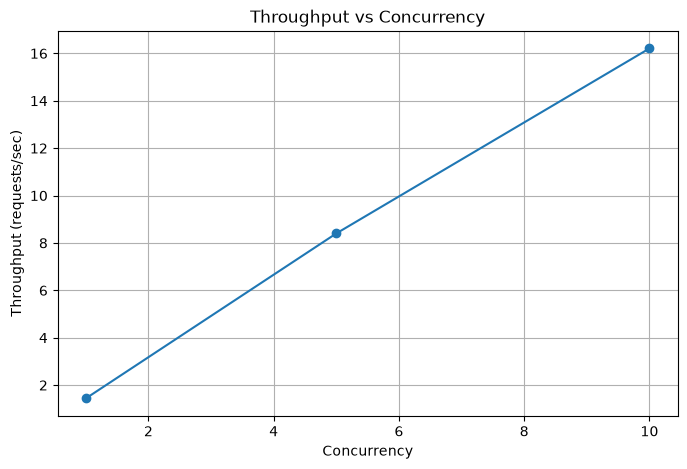

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["concurrency"],
    df["req_per_sec"],
    marker="o"
)

plt.xlabel("Concurrency")
plt.ylabel("Throughput (requests/sec)")
plt.title("Throughput vs Concurrency")
plt.grid(True)

plt.show()

## 7. Latency Percentiles vs Concurrency

P50, P95, and P99 latency are plotted to observe both typical request
performance and tail latency.

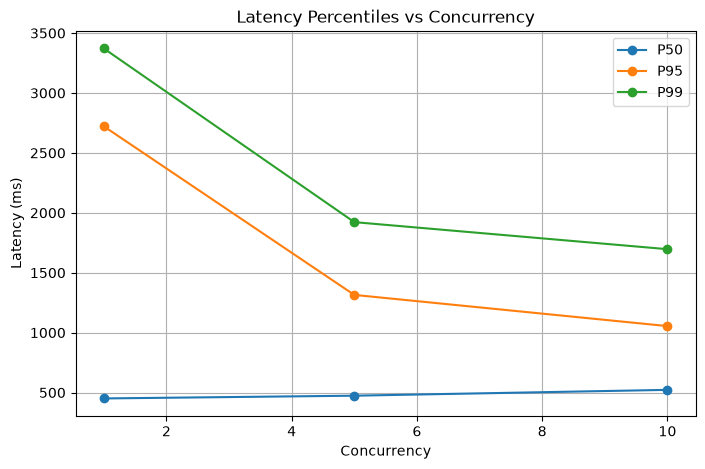

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["concurrency"],
    df["p50_ms"],
    marker="o",
    label="P50"
)

plt.plot(
    df["concurrency"],
    df["p95_ms"],
    marker="o",
    label="P95"
)

plt.plot(
    df["concurrency"],
    df["p99_ms"],
    marker="o",
    label="P99"
)

plt.xlabel("Concurrency")
plt.ylabel("Latency (ms)")
plt.title("Latency Percentiles vs Concurrency")
plt.legend()
plt.grid(True)

plt.show()

## 8. Success Rate

The success rate indicates the percentage of requests that completed with a
successful HTTP response.

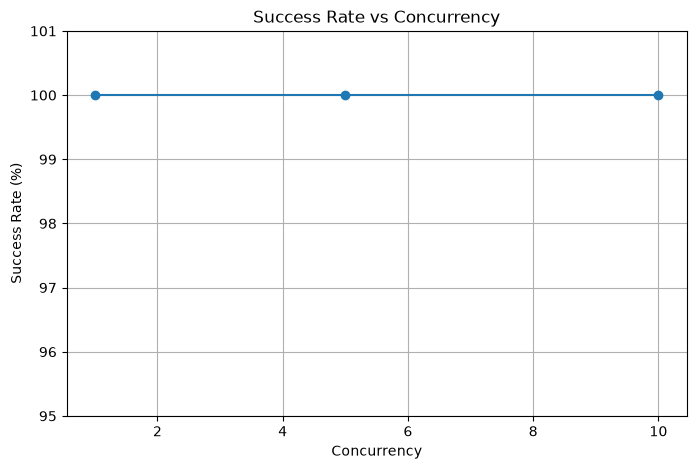

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["concurrency"],
    df["success_rate"],
    marker="o"
)

plt.xlabel("Concurrency")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate vs Concurrency")
plt.ylim(95, 101)
plt.grid(True)

plt.show()

## 9. Key Findings

In [8]:
total_requests = df["requests"].sum()
total_successful = df["successful"].sum()
total_failed = df["failed"].sum()

best = df.loc[df["req_per_sec"].idxmax()]

print(f"Total requests tested       : {total_requests:,}")
print(f"Successful requests         : {total_successful:,}")
print(f"Failed requests             : {total_failed:,}")
print(
    f"Overall success rate        : "
    f"{total_successful / total_requests * 100:.2f}%"
)
print(
    f"Highest observed throughput : "
    f"{best['req_per_sec']:.2f} requests/sec"
)
print(
    f"Concurrency at peak         : "
    f"{int(best['concurrency'])}"
)

Total requests tested       : 1,600
Successful requests         : 1,600
Failed requests             : 0
Overall success rate        : 100.00%
Highest observed throughput : 16.21 requests/sec
Concurrency at peak         : 10


### Observations

The application successfully processed all 1,600 requests across the tested
workloads, resulting in a 100% success rate.

Throughput increased substantially with concurrency, from approximately
1.44 requests/sec at concurrency 1 to 8.40 requests/sec at concurrency 5 and
16.21 requests/sec at concurrency 10.

Median latency remained relatively stable, ranging from approximately 451 ms
to 522 ms. However, P95 and P99 latency were considerably higher than the
median, indicating the presence of slower outlier requests.

The benchmark therefore demonstrates that the application benefits from
concurrent request processing, while also showing that tail latency remains an
area for potential optimization.

## 10. Limitations

The following limitations apply to this benchmark:

- The Flask application was tested using the local development server.
- PostgreSQL was hosted remotely on Supabase.
- All requests originated from a single client machine.
- The maximum tested concurrency was 10.
- The benchmark does not establish the theoretical maximum capacity of the
  application.
- Each successful request permanently created a database record.
- Test URLs were approximately 1,000 characters long.
- Network conditions between the application and remote database can affect
  latency.

## 11. Conclusion

Under the tested workloads, the URL Shortener achieved a 100% success rate
across 1,600 requests.

The highest observed throughput was 16.21 requests/sec at a concurrency level
of 10. Median latency remained below approximately 550 ms, although higher
percentile measurements showed significantly slower outlier requests.

These results establish a baseline for future performance optimization,
particularly around PostgreSQL connection management and database access.

# Appendix A — Load Testing Script

The following is the complete Python script used to perform the load tests.

The script was executed separately from this notebook. It generates the test
requests, measures response latency, reports progress in real time, and saves
the resulting benchmark data to `load_test_results.csv`.

In [9]:
from IPython.display import Code, display

display(
    Code(
        "load_test.py",
        language="python"
    )
)

import asyncio
import aiohttp
import random
import string
import time
import statistics
import csv
import sys


BASE_URL = "http://127.0.0.1:5000/"
ENDPOINT = BASE_URL + "/"

# Start small.
TESTS = [
    (100, 1),
    (500, 5),
    (1000, 10),
    # (2500, 25),   # Uncomment only after the above are healthy
    # (5000, 50),
]

URL_LENGTH = 1_000       # Start with 1 KB, NOT 10 KB

REQUEST_TIMEOUT = 15     # Individual request timeout
TEST_TIMEOUT = 120       # Maximum time for one complete test

RESULT_FILE = "load_test_results.csv"


def random_string(length):
    chars = string.ascii_letters + string.digits
    return ''.join(random.choices(chars, k=length))


def generate_long_url():
    half = URL_LENGTH // 2

    return (
        "https://example.com/"
        + random_string(half)
        + "?"
        + random_string(half)
    )


async def send_request(session, request_id):

    url = generate_long_url()

    start = time.perf_counter()

    try:
        async with session.post(
            ENDPOINT,
            data={"url": url},
            timeout=aiohttp.ClientTimeout(
                total=REQUEST_TIMEOUT
            )
        ) as response:

            await response.read()

            elapsed = time.perf_counter() - start

            return {
                "id": request_id,
                "status": response.status,
                "time": elapsed,
                "success": 200 <= response.status < 300,
                "error": ""
            }

    except asyncio.TimeoutError:

        elapsed = time.perf_counter() - start

        return {
            "id": request_id,
            "status": 0,
            "time": elapsed,
            "success": False,
            "error": "TIMEOUT"
        }

    except Exception as e:

        elapsed = time.perf_counter() - start

        return {
            "id": request_id,
            "status": 0,
            "time": elapsed,
            "success": False,
            "error": str(e)
        }


async def worker(session, queue, results):

    while True:

        request_id = await queue.get()

        if request_id is None:
            queue.task_done()
            return

        try:
            result = await send_request(
                session,
                request_id
            )

            results.append(result)

        finally:
            queue.task_done()


async def progress_monitor(
    results,
    total,
    start_time
):

    last_completed = 0

    while len(results) < total:

        completed = len(results)

        if completed != last_completed:

            elapsed = time.perf_counter() - start_time

            successful = sum(
                r["success"]
                for r in results
            )

            failed = completed - successful

            rate = (
                completed / elapsed
                if elapsed > 0
                else 0
            )

            avg = (
                statistics.mean(
                    r["time"]
                    for r in results
                )
                if results
                else 0
            )

            percent = (
                completed / total * 100
            )

            bar_length = 30

            filled = int(
                bar_length * completed / total
            )

            bar = (
                "█" * filled
                + "░" * (bar_length - filled)
            )

            print(
                f"\r[{bar}] "
                f"{completed}/{total} "
                f"({percent:5.1f}%) "
                f"| OK: {successful} "
                f"| FAIL: {failed} "
                f"| {rate:6.2f} req/s "
                f"| avg: {avg * 1000:7.1f} ms",
                end="",
                flush=True
            )

            last_completed = completed

        await asyncio.sleep(0.1)


async def run_test(
    total_requests,
    concurrency
):

    print()
    print("=" * 80)
    print("LOAD TEST")
    print("=" * 80)

    pr

# Appendix B — Raw Terminal Output

The following is the original terminal output generated during the benchmark.

The raw output is included for reproducibility and comparison with the
processed results presented earlier.

In [10]:
from IPython.display import Code, display

display(
    Code(
        "load_test_output.txt",
        language="text"
    )
)

================================================================================
LOAD TEST
================================================================================
Endpoint       : http://127.0.0.1:5000//
Requests       : 100
Concurrency    : 1
URL length     : ~1,000 characters
Request timeout: 15s
Test timeout   : 120s

[█████████████████████████████░] 99/100 ( 99.0%) | OK: 99 | FAIL: 0 |   1.43 req/s | avg:   696.6 ms

--------------------------------------------------------------------------------
RESULTS
--------------------------------------------------------------------------------
Completed           : 100/100
Successful          : 100
Failed              : 0
Success rate        : 100.00%
Total elapsed       : 69.531 s
Average latency     : 694.52 ms
Minimum latency     : 377.88 ms
Maximum latency     : 3371.67 ms
P50 latency         : 450.76 ms
P95 latency         : 2721.93 ms
P99 latency         : 3371.67 ms
Throughput          : 1.44 req/s

STATUS CODES
--------------------------------------------------------------------------------
200: 100
================================================================================

Cooling down for 5 seconds...

================================================================================
LOAD TEST
================================================================================
Endpoint       : http://127.0.0.1:5000//
Requests       : 500
Concurrency    : 5
URL length     : ~1,000 characters
Request timeout: 15s
Test timeout   : 120s

[█████████████████████████████░] 499/500 ( 99.8%) | OK: 499 | FAIL: 0 |   8.40 req/s | avg:   592.5 ms

--------------------------------------------------------------------------------
RESULTS
--------------------------------------------------------------------------------
Completed           : 500/500
Successful          : 500
Failed              : 0
Success rate        : 100.00%
Total elapsed       : 59.515 s
Average latency     : 592.57 ms
Minimum latency     : 373.11 ms
Maximum latency     : 2142.71 ms
P50 latency         : 473.72 ms
P95 latency         : 1314.81 ms
P99 latency         : 1922.13 ms
Throughput          : 8.40 req/s

STATUS CODES
--------------------------------------------------------------------------------
200: 500
================================================================================

Cooling down for 5 seconds...

================================================================================
LOAD TEST
================================================================================
Endpoint       : http://127.0.0.1:5000//
Requests       : 1,000
Concurrency    : 10
URL length     : ~1,000 characters
Request timeout: 15s
Test timeout   : 120s

[█████████████████████████████░] 996/1000 ( 99.6%) | OK: 996 | FAIL: 0 |  16.16 req/s | avg:   615.4 ms

--------------------------------------------------------------------------------
RESULTS
--------------------------------------------------------------------------------
Completed           : 1,000/1,000
Successful          : 1,000
Failed              : 0
Success rate        : 100.00%
Total elapsed       : 61.700 s
Average latency     : 614.82 ms
Minimum latency     : 366.44 ms
Maximum latency     : 2931.23 ms
P50 latency         : 522.34 ms
P95 latency         : 1054.53 ms
P99 latency         : 1696.44 ms
Throughput          : 16.21 req/s

STATUS CODES
--------------------------------------------------------------------------------
200: 1,000
================================================================================

Cooling down for 5 seconds...

================================================================================
ALL TESTS COMPLETE
================================================================================
Results saved to: load_test_results.csv